In [56]:
%pip install matplotlib seaborn
%pip install pandas matplotlib seaborn scipy
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
pd.set_option('display.max_columns', None)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
df_raw = pd.read_csv('master_energy_data.csv')

config_cols = [c for c in df_raw.columns if c.startswith('Config_')]
df_raw[config_cols] = df_raw[config_cols].fillna('default')

df_clean = df_raw[df_raw['is_outlier'] == False].copy()

df_clean = df_clean[df_clean['duration_ms'] > 0]

df_clean['duration_sec'] = df_clean['duration_ms'] / 1000

df_clean['g_total_computed'] = (
    df_clean['g_cpu'] + df_clean['g_screen'] + df_clean['g_wifi'] + 
    df_clean['g_mobile'] + df_clean['g_audio'] + df_clean['g_flash'] + 
    df_clean['g_gnss'] + df_clean['g_sens']
)

In [58]:
from IPython.display import display, HTML

apps_list = df_raw['App'].unique()


for app in apps_list:
    df_app = df_raw[df_raw['App'] == app].copy()
    relevant_configs = [c for c in df_app.columns if c.startswith('Config_') and df_app[c].nunique() > 1]
    
    if not relevant_configs:
        print(f"🔹 {app}: Total {len(df_app)} (OK)")
        print("-" * 60)
        continue

    unique_values = [df_app[c].unique() for c in relevant_configs]
    full_index = pd.MultiIndex.from_product(unique_values, names=relevant_configs)
    actual_counts = df_app.groupby(relevant_configs).size()
    
    check_df = actual_counts.reindex(full_index, fill_value=0).reset_index(name='Count')
    
    min_count = check_df['Count'].min()
    max_count = check_df['Count'].max()
    mode_count = check_df[check_df['Count'] > 0]['Count'].mode()
    
    expected = mode_count[0] if len(mode_count) > 0 else 15

    missing_scenarios = check_df[check_df['Count'] == 0]
    inconsistent_scenarios = check_df[(check_df['Count'] != expected) & (check_df['Count'] > 0)]
    
    if not missing_scenarios.empty:
        status = f"❌ CRITICAL: Missing {len(missing_scenarios)}!"
        color = "darkred"
        show_table = True
    elif not inconsistent_scenarios.empty:
        status = f"⚠️ ALERT: Changing variables ({min_count} a {max_count})"
        color = "orange"
        show_table = True
    else:
        status = f"✅ OK (All have {expected})"
        color = "green"
        show_table = False

    display(HTML(f"<h3 style='color:{color}; margin-bottom:0;'>{app} - {status}</h3>"))
    
    if show_table:
        print(f"Expected: {expected} executions.")
        
        if not missing_scenarios.empty:
            display(missing_scenarios.style.applymap(lambda x: "background-color: #ffcccc", subset=['Count']))
            
        if not inconsistent_scenarios.empty:
            display(inconsistent_scenarios)
    else:
        print(f"Tested Variables: {', '.join([c.replace('Config_', '') for c in relevant_configs])}")

    print("-" * 60)

Tested Variables: Duration, Brightness, Theme, Airplane, Saving, Refresh
------------------------------------------------------------


Tested Variables: Duration, Flashpower
------------------------------------------------------------


Tested Variables: Duration, Brightness, Theme, Airplane, Saving, Refresh
------------------------------------------------------------


Tested Variables: Brightness, Theme, Airplane, Saving, Refresh, Message
------------------------------------------------------------


Tested Variables: Duration, Brightness, Theme, Airplane, Saving, Refresh, Resolution
------------------------------------------------------------


In [59]:


def convert_mah_to_joules(mah, volts):
    return mah * volts * 3.6

def get_primary_metric_power(row):
    if row['App'] in ['IG', 'WPP', 'LIGHT']:
        base_mah = row['t_total']
    elif row['App'] in ['YT', 'TT']:
        base_mah = row['g_total_computed'] - row['r_total']
    else:
        base_mah = row['g_total_computed']

    volts = row['volt_mv'] / 1000.0 
    energy_joules = base_mah * volts * 3.6
    
    if row['duration_sec'] > 0:
        power_watts = energy_joules / row['duration_sec']
    else:
        power_watts = 0
    
    return power_watts

df_clean['Smart_Metric_W'] = df_clean.apply(get_primary_metric_power, axis=1)
df_clean['t_total_joules'] = df_clean.apply(lambda row: convert_mah_to_joules(row['t_total'], row['volt_mv'] / 1000.0), axis=1)
df_clean['r_total_joules'] = df_clean.apply(lambda row: convert_mah_to_joules(row['r_total'], row['volt_mv'] / 1000.0), axis=1)

initial_count = len(df_clean)
df_clean = df_clean[df_clean['Smart_Metric_W'] > 0.05].copy()

removed_count = initial_count - len(df_clean)

apps = df_clean['App'].unique()
data = [df_clean[df_clean['App'] == app]['Smart_Metric_W'].values for app in apps]
stat, p_value = stats.kruskal(*data)

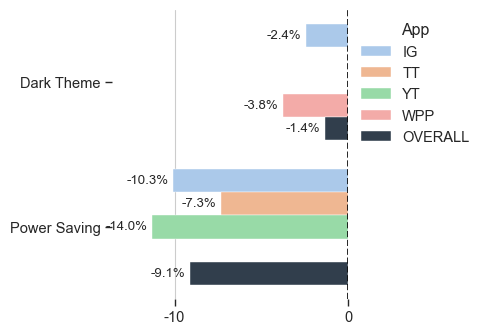

In [60]:
metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df_clean.columns else 'Smart_Metric_mAh_sec'

comparisons = {
    'Config_Theme': {'col': 'Config_Theme', 'base': 'light', 'target': 'dark', 'label': 'Dark Theme'},
    'Config_Saving': {'col': 'Config_Saving', 'base': 'off', 'target': 'on', 'label': 'Power Saving'}
}

impact_data = []
apps_to_eval = list(df_clean['App'].unique())

for app in apps_to_eval + ['OVERALL']:
    df_eval = df_clean if app == 'OVERALL' else df_clean[df_clean['App'] == app]
    
    for key, config in comparisons.items():
        col = config['col']
        if col not in df_eval.columns: continue
        
        available_vals = df_eval[col].unique()
        if config['base'] in available_vals and config['target'] in available_vals:
            
            values_base = df_eval[df_eval[col] == config['base']][metric].values
            values_target = df_eval[df_eval[col] == config['target']][metric].values
            
            if len(values_base) >= 3 and len(values_target) >= 3:
                
                stat, p_val = stats.mannwhitneyu(values_base, values_target, alternative='two-sided')
                
                if app == 'OVERALL':
                    df_base = df_eval[df_eval[col] == config['base']]
                    df_target = df_eval[df_eval[col] == config['target']]
                    
                    means_base_by_app = df_base.groupby('App')[metric].mean()
                    means_target_by_app = df_target.groupby('App')[metric].mean()
                    
                    mean_base = means_base_by_app.mean()
                    mean_target = means_target_by_app.mean()
                else:
                    mean_base = values_base.mean()
                    mean_target = values_target.mean()
                
                if p_val < 0.05 or app == 'OVERALL':
                    if mean_base > 0:
                        diff_pct = ((mean_target - mean_base) / mean_base) * 100
                        
                        impact_data.append({
                            'App': app,
                            'Variable': config['label'],
                            'Impact_Pct': diff_pct,
                            'P_Value': p_val
                        })

df_impact = pd.DataFrame(impact_data)


if not df_impact.empty:
    plt.figure(figsize=(5, 3.5)) 
    
    apps_presentes = ['IG', 'TT', 'YT'] 
    if 'WPP' in df_impact['App'].values: apps_presentes.append('WPP')
    hue_order = apps_presentes + (['OVERALL'] if 'OVERALL' in df_impact['App'].values else[])
    
    desired_order = [cfg['label'] for cfg in comparisons.values()]
    final_order =[o for o in desired_order if o in df_impact['Variable'].unique()]
    
    apps_presentes = ['IG', 'TT', 'YT'] 
    if 'WPP' in df_impact['App'].values:
        apps_presentes.append('WPP')

    hue_order = apps_presentes +['OVERALL'] if 'OVERALL' in df_impact['App'].values else apps_presentes
    
    pastel_colors = sns.color_palette("pastel", len(apps_presentes))
    custom_palette = {app: color for app, color in zip(apps_presentes, pastel_colors)}
    custom_palette['OVERALL'] = '#2c3e50' 
    
    desired_order = [cfg['label'] for cfg in comparisons.values()]
    final_order = [o for o in desired_order if o in df_impact['Variable'].unique()]
    
    ax = sns.barplot(
        data=df_impact, y='Variable', x='Impact_Pct', 
        hue='App', hue_order=hue_order, order=final_order,
        palette=custom_palette, 
        edgecolor='white', linewidth=0.3
    )
    sns.despine(bottom = True, left = True)
    
    plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
    
    ax.set_xscale('symlog', linthresh=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))
    
    plt.title('', fontsize=11, fontweight='bold')
    plt.xlabel('', fontsize=10)
    plt.ylabel('')
    
    for container in ax.containers:
        if container.datavalues.size > 0:
            ax.bar_label(container, fmt='%+.1f%%', padding=3, fontsize=9.5)
        
    plt.legend(title='App', bbox_to_anchor=(1, 1), loc='upper left')
    plt.margins(x=0.2)
    plt.tight_layout()
    
    #plt.savefig("binary_res.pdf", bbox_inches='tight') 
    plt.show()
else:
    print("No significant impacts found for the tested variables.")

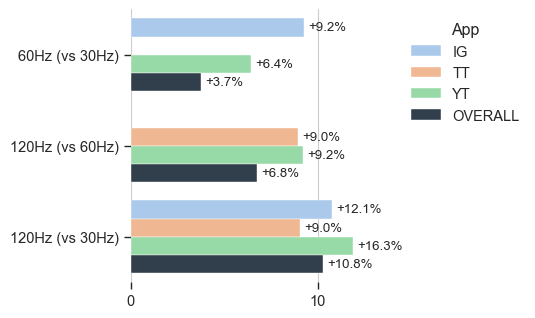

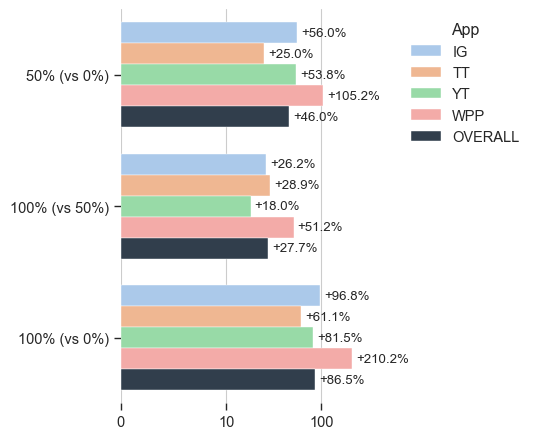

In [61]:
metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df_clean.columns else 'Smart_Metric_mAh_sec'

def plot_impact_analysis(df, comparisons, title, graphsize, overall = True):
    impact_data = []
    apps_to_eval = list(df['App'].unique())

    for app in apps_to_eval + ['OVERALL']:
        df_eval = df if app == 'OVERALL' else df[df['App'] == app]
        
        for key, config in comparisons.items():
            col = config['col']
            if col not in df_eval.columns: continue
            
            vals_base = df_eval[df_eval[col] == config['base']][metric].values
            vals_target = df_eval[df_eval[col] == config['target']][metric].values
            
            if len(vals_base) >= 3 and len(vals_target) >= 3:
                stat, p_val = stats.mannwhitneyu(vals_base, vals_target, alternative='two-sided')
                
                if app == 'OVERALL':
                    df_base = df_eval[df_eval[col] == config['base']]
                    df_target = df_eval[df_eval[col] == config['target']]
                    
                    means_base_by_app = df_base.groupby('App')[metric].mean()
                    means_target_by_app = df_target.groupby('App')[metric].mean()
                    
                    mean_base = means_base_by_app.mean()
                    mean_target = means_target_by_app.mean()
                else:
                    mean_base = vals_base.mean()
                    mean_target = vals_target.mean()
                
                if p_val < 0.05:
                    if mean_base > 0:
                        diff_pct = ((mean_target - mean_base) / mean_base) * 100
                        impact_data.append({
                            'App': app,
                            'Variable': config['label'],
                            'Impact_Pct': diff_pct,
                            'P_Value': p_val
                        })

    df_impact = pd.DataFrame(impact_data)

    if not df_impact.empty:
        plt.figure(figsize=(graphsize))
        
        apps_presentes = ['IG', 'TT', 'YT'] 
        if 'WPP' in df_impact['App'].values and overall:
            apps_presentes.append('WPP')

        hue_order = apps_presentes +['OVERALL'] if 'OVERALL' in df_impact['App'].values and overall else apps_presentes
        
        pastel_colors = sns.color_palette("pastel", len(apps_presentes))
        custom_palette = {app: color for app, color in zip(apps_presentes, pastel_colors)}
        custom_palette['OVERALL'] = '#2c3e50' 
        
        desired_order = [cfg['label'] for cfg in comparisons.values()]
        final_order = [o for o in desired_order if o in df_impact['Variable'].unique()]

        ax = sns.barplot(
            data=df_impact, y='Variable', x='Impact_Pct', 
            hue='App', hue_order=hue_order, 
            order=final_order,
            palette=custom_palette, 
            edgecolor='white',      
            linewidth=0.3
        )
        
        ax.set_xscale('symlog', linthresh=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))
        
        plt.title('', fontsize=10, fontweight='bold')
        plt.xlabel('', fontsize=12)
        plt.ylabel('')
        
        for container in ax.containers:
            if container.datavalues.size > 0:
                ax.bar_label(container, fmt='%+.1f%%', padding=3, fontsize=9.5)
        
        plt.legend(title='App', bbox_to_anchor=(1, 1), loc='upper left')
        plt.margins(x=0.2)
        plt.tight_layout()
        sns.despine(bottom = True, left = True)
        
        #title_file = f"{title.replace(' ', '_').lower()}_impact.png"
        #plt.savefig(title_file, dpi=900) 

        #imagePath = Image.open(title_file)
        #pdf_path = title_file.replace(".png", ".pdf")
        #images = [imagePath]
        #images[0].save(pdf_path, "PDF" ,resolution=100.0, save_all=True, append_images=images[1:])
        
        plt.show()
    else:
        print(f"No significant impacts found for: {title}")

comps_refresh = {
    'ref_30_60':  {'col': 'Config_Refresh', 'base': 'fps30', 'target': 'fps60',  'label': '60Hz (vs 30Hz)'},
    'ref_60_120': {'col': 'Config_Refresh', 'base': 'fps60', 'target': 'fps120', 'label': '120Hz (vs 60Hz)'},
    'ref_30_120': {'col': 'Config_Refresh', 'base': 'fps30', 'target': 'fps120', 'label': '120Hz (vs 30Hz)'}
}

plot_impact_analysis(df_clean, comps_refresh, "Refresh Rate Consumption Impact", (5.5,5/1.5))

comps_brightness = {
    'bright_zero_half':  {'col': 'Config_Brightness', 'base': 'zero', 'target': 'half',  'label': '50% (vs 0%)'},
    'bright_half_full':  {'col': 'Config_Brightness', 'base': 'half', 'target': 'full',  'label': '100% (vs 50%)'},
    'bright_zero_full':  {'col': 'Config_Brightness', 'base': 'zero', 'target': 'full',  'label': '100% (vs 0%)'},
}

plot_impact_analysis(df_clean, comps_brightness, "Brightness Consumption Impact", (5.5,5/1.1))

In [62]:
def plot_impact_analysis(df, comparisons, title, overall=True, figsize=(5.5, 3), x_limits=None, target_metric=None, noLegend=False):
    """
    Função com o estilo visual escolhido (gradientes, barras limpas, symlog),
    com a opção de escolher qual métrica avaliar.
    Imprime no final os valores ignorados por falta de significância estatística.
    """
    impact_data = []
    ignored_data =[]
    
    apps_to_eval = list(df['App'].unique())
    
    if target_metric:
        metric = target_metric
    else:
        metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df.columns else 'Smart_Metric_mAh_sec'
    # ------------------------------------------------------------
        
    apps_to_loop = apps_to_eval + ['OVERALL'] if overall else apps_to_eval

    for app in apps_to_loop:
        df_eval = df if app == 'OVERALL' else df[df['App'] == app]
        
        for key, config in comparisons.items():
            col = config['col']
            if col not in df_eval.columns: continue
            
            available_vals = df_eval[col].unique()
            if config['base'] in available_vals and config['target'] in available_vals:
                
                values_base = df_eval[df_eval[col] == config['base']][metric].values
                values_target = df_eval[df_eval[col] == config['target']][metric].values
                
                if len(values_base) >= 3 and len(values_target) >= 3:
                    stat, p_val = stats.mannwhitneyu(values_base, values_target, alternative='two-sided')
                    
                    mean_base = values_base.mean()
                    mean_target = values_target.mean()
                    
                    if mean_base > 0:
                        diff_pct = ((mean_target - mean_base) / mean_base) * 100
                        
                        if p_val < 0.05:
                            impact_data.append({
                                'App': app,
                                'Variable': config['label'],
                                'Impact_Pct': diff_pct,
                                'P_Value': p_val
                            })
                        else:
                            ignored_data.append({
                                'App': app,
                                'Variable': config['label'],
                                'Impact_Pct (Ignored)': diff_pct,
                                'P_Value': p_val,
                                'Reason': 'p-value >= 0.05'
                            })
                else:
                    ignored_data.append({
                        'App': app,
                        'Variable': config['label'],
                        'Impact_Pct (Ignored)': None,
                        'P_Value': None,
                        'Reason': f'Amostras insuficientes ({len(values_base)} vs {len(values_target)})'
                    })

    df_impact = pd.DataFrame(impact_data)

    if not df_impact.empty:
        plt.figure(figsize=figsize)
        
        apps_presentes = ['LIGHT','IG', 'TT', 'YT', 'WPP']  
        
        hue_order =[a for a in apps_presentes if a in df_impact['App'].values] 
        
        pastel_colors = sns.color_palette("pastel", len(hue_order))
        custom_palette = {app: color for app, color in zip(hue_order, pastel_colors)}
         
        
        custom_palette['OVERALL'] = '#2c3e50'
        
        ax = sns.barplot(
            data=df_impact, y='Variable', x='Impact_Pct', 
            hue='App', hue_order=hue_order, 
            palette=custom_palette, 
            edgecolor='white', linewidth=0.3
        )

        if 'LIGHT' in hue_order:
            light_index = hue_order.index('LIGHT')
            shades_light =['#c8a2c8', '#a77bb0', '#865494', '#652c78']
            for i in range(3):
                patch_idx = light_index * 3 + i
                if patch_idx < len(ax.patches):
                    ax.patches[patch_idx].set_facecolor(shades_light[i % len(shades_light)])


        if 'WPP' in hue_order:
            wpp_index = hue_order.index('WPP')
            shades_wpp =['#f3a6b6', '#e08c9e', '#c77285', '#ae5a6c']
            for i in range(3):
                patch_idx = wpp_index * 3 + i
                if patch_idx < len(ax.patches):
                    ax.patches[patch_idx].set_facecolor(shades_wpp[i % len(shades_wpp)])

        if 'YT' in hue_order:
            yt_index = hue_order.index('YT')
            shades_yt =['#98daa7', '#77c48e', '#56a075', '#34885c']
            for i in range(3):
                patch_idx = yt_index * 3 + i
                if patch_idx < len(ax.patches):
                    ax.patches[patch_idx].set_facecolor(shades_yt[i % len(shades_yt)])
        
        
        ax.set_xscale('symlog', linthresh=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))
        
        if x_limits is not None:
            ax.set_xlim(x_limits)

        display_title = title if title else ""
        if 'LIGHT' in df_impact['App'].values and overall or 'WPP' in df_impact['App'].values and overall or noLegend:
            ax.legend_.remove()   
        else:
            plt.legend(title='App', bbox_to_anchor=(1, 1), loc='upper left')

        plt.title(display_title, fontsize=10, fontweight='bold')
        plt.xlabel('', fontsize=12)
        plt.ylabel('')
        
        for container in ax.containers:
            if container.datavalues.size > 0:
                ax.bar_label(container, fmt='%+.1f%%', padding=3, fontsize=9.5)


       # save_name = "_".join(hue_order)
       # save_title = f"duracao_{save_name}_impact"
        sns.despine(bottom = True, left = True)
       # plt.savefig(f"{save_title}.pdf", bbox_inches='tight') 
        plt.show()
       
    else:
        print(f"⚠️ No significant impacts found for: {title}")

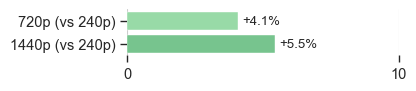

In [63]:
global_limits = (-5, 0)

comps_resolution = {
    'res_low_med':  {'col': 'Config_Resolution', 'base': 'low',    'target': 'medium',  'label': '720p (vs 240p)'},
    'res_med_high': {'col': 'Config_Resolution', 'base': 'medium', 'target': 'highest', 'label': '1440p (vs 720p)'},
    'res_low_high': {'col': 'Config_Resolution', 'base': 'low',    'target': 'highest', 'label': '1440p (vs 240p)'}
}

plot_impact_analysis(
    df_clean, 
    comps_resolution, 
    "", 
    figsize=(3.5,0.6)
    ,x_limits=(0, 10), noLegend=True
)






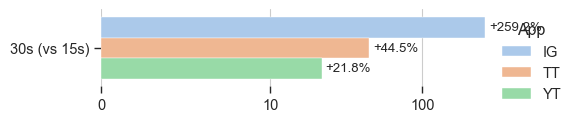

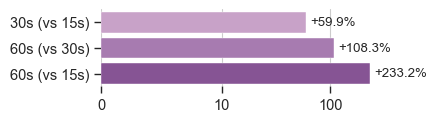

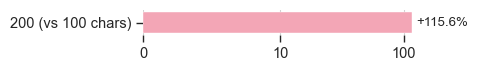

In [64]:
comps_duration = {
    'dur_15_30': {'col': 'Config_Duration', 'base': 's15', 'target': 's30', 'label': '30s (vs 15s)'}
}

target_apps =['YT', 'IG', 'TT']
df_dur = df_clean[df_clean['App'].isin(target_apps)].copy()

metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df_dur.columns else 'Smart_Metric_mAh_sec'
if metric != 'Smart_Metric_W':
    df_dur['Smart_Metric_W'] = df_dur[metric] * (df_dur['volt_mv'] / 1000) * 3600
    
df_dur['Energy_Joules'] = (df_dur['Smart_Metric_W'] / 1000) * df_dur['duration_sec']

plot_impact_analysis(
    df=df_dur, 
    comparisons=comps_duration, 
    title="", 
    overall=True, 
    target_metric='Energy_Joules',
    figsize=(5,1)
)

comps_duration = {
    'dur_15_30': {'col': 'Config_Duration', 'base': 's15', 'target': 's30', 'label': '30s (vs 15s)'},
    'dur_30_60': {'col': 'Config_Duration', 'base': 's30', 'target': 's60', 'label': '60s (vs 30s)'},
    'dur_15_60': {'col': 'Config_Duration', 'base': 's15', 'target': 's60', 'label': '60s (vs 15s)'}
}

target_apps =['LIGHT']
df_dur = df_clean[df_clean['App'].isin(target_apps)].copy()

metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df_dur.columns else 'Smart_Metric_mAh_sec'
if metric != 'Smart_Metric_W':
    df_dur['Smart_Metric_W'] = df_dur[metric] * (df_dur['volt_mv'] / 1000) * 3600
    
df_dur['Energy_Joules'] = (df_dur['Smart_Metric_W'] / 1000) * df_dur['duration_sec']

plot_impact_analysis(
    df=df_dur, 
    comparisons=comps_duration, 
    title="", 
    overall=True, 
    target_metric='Energy_Joules',
    figsize=(3.5,1)
)

comps_message = {
    'msg_short_med':  {'col': 'Config_Message', 'base': 'short', 'target': 'medium', 'label': '200 (vs 100 chars)'},
}

target_apps =['WPP']
df_dur = df_clean[df_clean['App'].isin(target_apps)].copy()

metric = 'Smart_Metric_W' if 'Smart_Metric_W' in df_dur.columns else 'Smart_Metric_mAh_sec'
if metric != 'Smart_Metric_W':
    df_dur['Smart_Metric_W'] = df_dur[metric] * (df_dur['volt_mv'] / 1000) * 3600
    
df_dur['Energy_Joules'] = (df_dur['Smart_Metric_W'] / 1000) * df_dur['duration_sec']

plot_impact_analysis(
    df=df_dur, 
    comparisons=comps_message, 
    title="", 
    overall=True, 
    target_metric='Energy_Joules', 
    figsize=(3.5,1/3)
)


